# CNN for Classification
---
In this notebook, we define **and train** an CNN to classify images from the [Fashion-MNIST database](https://github.com/zalandoresearch/fashion-mnist).

### Load the [data](http://pytorch.org/docs/master/torchvision/datasets.html)

In this cell, we load in both **training and test** datasets from the FashionMNIST class.

In [1]:
#~~~~~~~~~#~~~~~~~~~#~~~~~~~~~#~~~~~~~~~#~~~~~~~~~#~~~~~~~~~#~~~~~~~~~#~~~~~~~~~
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
from torchvision.datasets import FashionMNIST

In [2]:
IMG = '../../../img'

In [3]:
data_transform = transforms.ToTensor()
train_data = FashionMNIST(
    root=IMG, train=True, download=True, transform=data_transform)
test_data = FashionMNIST(
    root=IMG, train=False, download=True, transform=data_transform)
print('Train data, number of images: ', len(train_data))
print('Test data, number of images: ', len(test_data))

Train data, number of images:  60000
Test data, number of images:  10000


In [4]:
batch_size = 20
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)
classes = (
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 
    'Sneaker', 'Bag', 'Ankle boot')

### Visualize some training data

This cell iterates over the training dataset, loading a random batch of image/label data, using `dataiter.next()`. It then plots the batch of images and labels in a `2 x batch_size/2` grid.

(1, 28, 28)


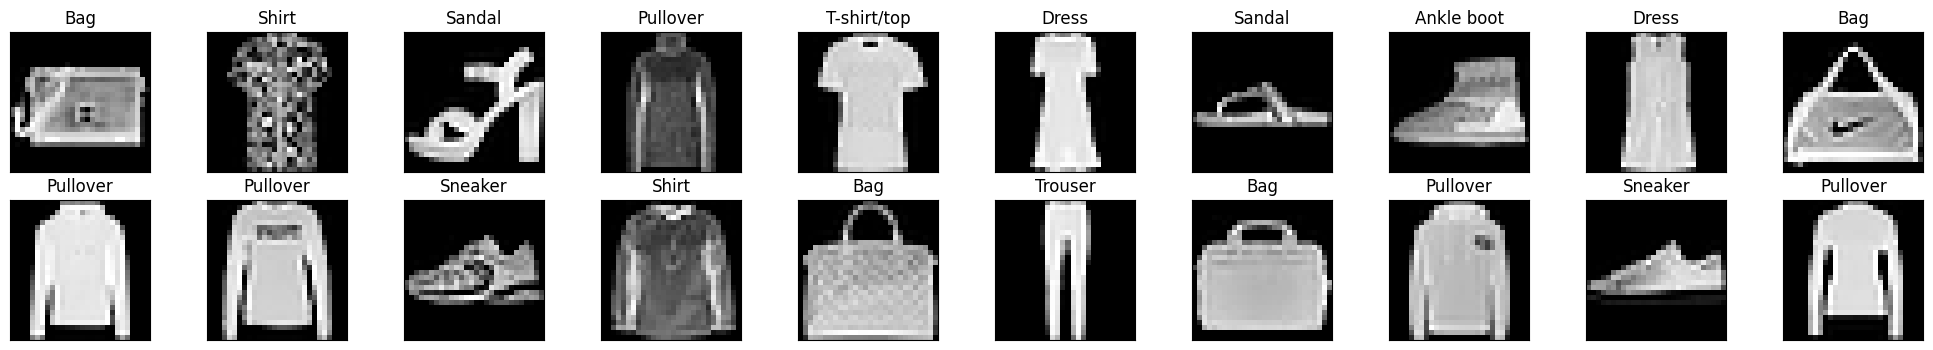

In [5]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()
print(images[0].shape)
fig = plt.figure(figsize=(25, 4))
for i in np.arange(batch_size):
    ax = fig.add_subplot(2, batch_size // 2, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[i]), cmap='gray')
    ax.set_title(classes[labels[i]])

### Define the network architecture

The various layers that make up any neural network are documented, [here](http://pytorch.org/docs/master/nn.html). For a convolutional neural network, we'll use a simple series of layers:
* Convolutional layers
* Maxpooling layers
* Fully-connected (linear) layers

You are also encouraged to look at adding [dropout layers](http://pytorch.org/docs/stable/nn.html#dropout) to avoid overfitting this data.

---

To define a neural network in PyTorch, you define the layers of a model in the function `__init__` and define the feedforward behavior of a network that employs those initialized layers in the function `forward`, which takes in an input image tensor, `x`. The structure of this Net class is shown below and left for you to fill in.

Note: During training, PyTorch will be able to perform backpropagation by keeping track of the network's feedforward behavior and using autograd to calculate the update to the weights in the network.

#### Define the Layers in ` __init__`
As a reminder, a conv/pool layer may be defined like this (in `__init__`):
```
# 1 input image channel (for grayscale images), 32 output channels/feature maps, 3x3 square convolution kernel
self.conv1 = nn.Conv2d(1, 32, 3)

# maxpool that uses a square window of kernel_size=2, stride=2
self.pool = nn.MaxPool2d(2, 2)      
```

#### Refer to Layers in `forward`
Then referred to in the `forward` function like this, in which the conv1 layer has a ReLu activation applied to it before maxpooling is applied:
```
x = self.pool(F.relu(self.conv1(x)))
```

You must place any layers with trainable weights, such as convolutional layers, in the `__init__` function and refer to them in the `forward` functio; any layers or functions that always behave in the same way, such as a pre-defined activation function, may appear in either the `__init__` or the `forward` function. In practice, you'll often see conv/pool layers defined in `__init__` and activations defined in `forward`.

#### Convolutional layer
The first convolution layer has been defined for you, it takes in a 1 channel (grayscale) image and outputs 10 feature maps as output, after convolving the image with 3x3 filters.

#### Flattening

Recall that to move from the output of a convoluttional/pooling layer to a linear layer, you must first flatten your extracted features into a vector. If you've used the deep learning library, Keras, you may have seen this done by `Flatten()`, and in PyTorch you can flatten an input `x` with `x = x.view(x.size(0), -1)`.

### TODO: Define the rest of the layers

It will be up to you to define the other layers in this network; we have some recommendations, but you may change the architecture and parameters as you see fit.

Recommendations/tips:
* Use at least two convolutional layers
* Your output must be a linear layer with 10 outputs (for the 10 classes of clothing)
* Use a dropout layer to avoid overfitting

In [26]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # 1 input image channel (grayscale), 10 output channels/feature maps
        # 3x3 square convolution kernel
        self.conv1 = nn.Conv2d(1, 10, 3)
        self.conv2 = nn.Conv2d(10, 20, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(20 * 5 * 5, 50) # 20 from conv2 out * 5x5 pooled size
        self.dropH = nn.Dropout(p=0.8)
        self.dropM = nn.Dropout(p=0.4)
        self.dropL = nn.Dropout(p=0.2)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.dropH(x)
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropM(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropL(x)
        x = self.fc2(x)
        return x

In [27]:
net = Net()
print(net)

Net(
  (conv1): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=500, out_features=50, bias=True)
  (dropH): Dropout(p=0.8, inplace=False)
  (dropM): Dropout(p=0.4, inplace=False)
  (dropL): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)


### TODO: Specify the loss function and optimizer

Learn more about [loss functions](http://pytorch.org/docs/master/nn.html#loss-functions) and [optimizers](http://pytorch.org/docs/master/optim.html) in the online documentation.

Note that for a classification problem like this, one typically uses cross entropy loss, which can be defined in code like: `criterion = nn.CrossEntropyLoss()`. PyTorch also includes some standard stochastic optimizers like stochastic gradient descent and Adam. You're encouraged to try different optimizers and see how your model responds to these choices as it trains.


In [28]:
## TODO: specify loss function (try categorical cross-entropy)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

### A note on accuracy

It's interesting to look at the accuracy of your network **before and after** training. This way you can really see that your network has learned something. In the next cell, let's see what the accuracy of an untrained network is (we expect it to be around 10% which is the same accuracy as just guessing for all 10 classes).

#### Variable

Before an input tensor can be processed by a model, it must be wrapped in a Variable wrapper; this wrapper gives PyTorch the ability to automatically track how this input changes as it passes through the network and automatically calculate the gradients needed for backpropagation.


In [29]:
correct = 0
total = 0
for images, labels in test_loader:
    #images = Variable(images)
    outputs = net(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum()
accuracy = 100 * correct / total
print('Accuracy before training: ', accuracy)

Accuracy before training:  tensor(10.4800)


### Train the Network

Below, we've defined a `train` function that takes in a number of epochs to train for. The number of epochs is how many times a network will cycle through the training dataset. 

Here are the steps that this training function performs as it iterates over the training dataset:

1. Wraps all tensors in Variables
2. Zero's the gradients to prepare for a forward pass
3. Passes the input through the network (forward pass)
4. Computes the loss (how far is the predicted classes are from the correct labels)
5. Propagates gradients back into the network’s parameters (backward pass)
6. Updates the weights (parameter update)
7. Prints out the calculated loss



In [30]:
def train(n_epochs):
    for epoch in range(n_epochs):
        running_loss = 0.
        for batch_i, data in enumerate(train_loader):
            inputs, labels = data
            inputs, labels = Variable(inputs), Variable(labels)        
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()            
            running_loss += loss.data.item()  #loss.data[0]
            if batch_i % 1000 == 999:    # print every 1000 mini-batches
                print(
                    f'Epoch: {epoch + 1}, Batch: {batch_i + 1}, Avg. Loss: '
                    f'{running_loss / 1000:.5f}')
                running_loss = 0.
    print('Finished Training')

In [35]:
n_epochs = 30
train(n_epochs)

Epoch: 1, Batch: 1000, Avg. Loss: 0.36822
Epoch: 1, Batch: 2000, Avg. Loss: 0.33369
Epoch: 1, Batch: 3000, Avg. Loss: 0.31407
Epoch: 2, Batch: 1000, Avg. Loss: 0.29038
Epoch: 2, Batch: 2000, Avg. Loss: 0.29133
Epoch: 2, Batch: 3000, Avg. Loss: 0.29290
Epoch: 3, Batch: 1000, Avg. Loss: 0.27204
Epoch: 3, Batch: 2000, Avg. Loss: 0.26682
Epoch: 3, Batch: 3000, Avg. Loss: 0.25822
Epoch: 4, Batch: 1000, Avg. Loss: 0.24691
Epoch: 4, Batch: 2000, Avg. Loss: 0.24898
Epoch: 4, Batch: 3000, Avg. Loss: 0.25159
Epoch: 5, Batch: 1000, Avg. Loss: 0.23533
Epoch: 5, Batch: 2000, Avg. Loss: 0.23913
Epoch: 5, Batch: 3000, Avg. Loss: 0.23689
Epoch: 6, Batch: 1000, Avg. Loss: 0.22050
Epoch: 6, Batch: 2000, Avg. Loss: 0.22932
Epoch: 6, Batch: 3000, Avg. Loss: 0.22549
Epoch: 7, Batch: 1000, Avg. Loss: 0.20335
Epoch: 7, Batch: 2000, Avg. Loss: 0.22345
Epoch: 7, Batch: 3000, Avg. Loss: 0.21808
Epoch: 8, Batch: 1000, Avg. Loss: 0.20394
Epoch: 8, Batch: 2000, Avg. Loss: 0.20961
Epoch: 8, Batch: 3000, Avg. Loss: 

### Test the Trained Network

Once you are satisfied with how the loss of your model has decreased, there is one last step: test!

You must test your trained model on a previously unseen dataset to see if it generalizes well and can accurately classify this new dataset. For FashionMNIST, which contains many pre-processed training images, a good model should reach **greater than 85% accuracy** on this test dataset. If you are not reaching this value, try training for a larger number of epochs, tweaking your hyperparameters, or adding/subtracting layers from your CNN.

In [36]:
test_loss = torch.zeros(1)
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))
net.eval()

for batch_i, data in enumerate(test_loader):
    inputs, labels = data
    # volatile means we do not have to track how the inputs change
    #inputs = Variable(inputs, volatile=True)
    #labels = Variable(labels, volatile=True)
    with torch.no_grad():
        inputs = Variable(inputs)
        labels = Variable(labels)
    outputs = net(inputs)
    loss = criterion(outputs, labels)
    test_loss += ((torch.ones(1) / (batch_i + 1)) * (loss.data - test_loss))
    _, predicted = torch.max(outputs.data, 1)
    correct = np.squeeze(predicted.eq(labels.data.view_as(predicted)))    
    # calculate test accuracy for *each* object class
    # we get the scalar value of correct items for a class, by calling
    # `correct[i].item()`
    for i in range(batch_size):
        label = labels.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1  
    # calculate test accuracy for *each* object class
    for i in range(batch_size):
        label = labels.data[i]
        class_correct[label] += correct[i]
        class_total[label] += 1

In [37]:
print(f'Test Loss: {test_loss.numpy()[0]:.6f}\n')
for i in range(10):
    if class_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            classes[i], 
            100 * class_correct[i] / class_total[i],
            class_correct[i], class_total[i]))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))     
print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

Test Loss: 0.444555

Test Accuracy of T-shirt/top: 86% (1726/2000)
Test Accuracy of Trouser: 97% (1942/2000)
Test Accuracy of Pullover: 82% (1652/2000)
Test Accuracy of Dress: 87% (1748/2000)
Test Accuracy of  Coat: 86% (1734/2000)
Test Accuracy of Sandal: 96% (1938/2000)
Test Accuracy of Shirt: 67% (1344/2000)
Test Accuracy of Sneaker: 95% (1918/2000)
Test Accuracy of   Bag: 97% (1950/2000)
Test Accuracy of Ankle boot: 96% (1920/2000)

Test Accuracy (Overall): 89% (17872/20000)


### Visualize sample test results

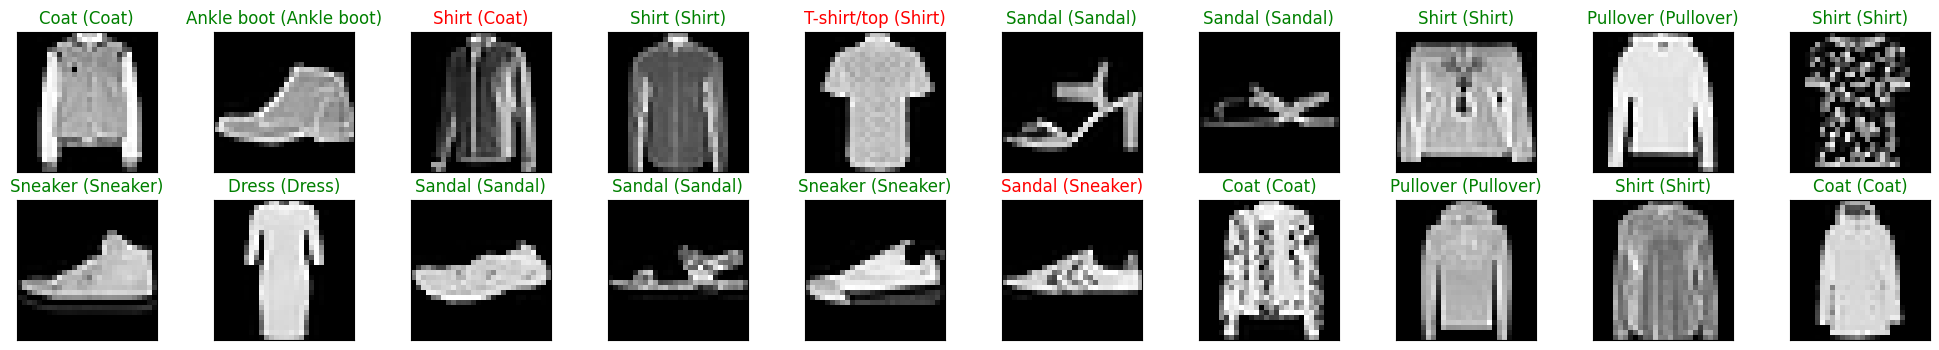

In [38]:
dataiter = iter(test_loader)
images, labels = next(dataiter)
with torch.no_grad():
    images = Variable(images)
# get predictions
preds = (
    np.squeeze(
        net(images)
        .data
        .max(1, keepdim=True)[1]
        .numpy()))
images = images.numpy()
fig = plt.figure(figsize=(25, 4))
for i in np.arange(batch_size):
    ax = fig.add_subplot(2, batch_size // 2, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[i]), cmap='gray')
    ax.set_title(
        f'{classes[preds[i]]} ({classes[labels[i]]})',
        color='green' if preds[i] == labels[i] else 'red')

### Question: What are some weaknesses of your model? (And how might you improve these in future iterations.)

**Answer**: Double-click and write answer, here.

### Save Your Best Model

Once you've decided on a network architecture and are satisfied with the test accuracy of your model after training, it's time to save this so that you can refer back to this model, and use it at a later data for comparison of for another classification task!

In [39]:
#!mkdir saved_models

In [40]:
model_dir = 'saved_models/'
model_name = 'fashion_mnist_cnn_small.pt'
torch.save(net.state_dict(), f'{model_dir}/{model_name}')

### Load a Trained, Saved Model

To instantiate a trained model, you'll first instantiate a new `Net()` and then initialize it with a saved dictionary of parameters (from the save step above).

In [41]:
net = Net()
net.load_state_dict(torch.load(f'{model_dir}/{model_name}'))
print(net)

Net(
  (conv1): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=500, out_features=50, bias=True)
  (dropH): Dropout(p=0.8, inplace=False)
  (dropM): Dropout(p=0.4, inplace=False)
  (dropL): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)
